In [1]:
from mpramnist.Reddy2023 import ReddyDataset
from mpramnist.Reddy2023 import LitModel_Reddy_Reg
from mpramnist.Reddy2023 import LitModel_Reddy_Clas

from mpramnist.models import HumanLegNet
from mpramnist.models import initialize_weights

from mpramnist import transforms as t

import torch.nn as nn
import torch.utils.data as data
import lightning.pytorch as L

BATCH_SIZE = 32
NUM_WORKERS = 16

/home/nios/miniconda3/envs/mpra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Regressions Task

In [2]:
train_transform = t.Compose([t.ReverseComplement(0.5),t.Seq2Tensor(),])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "regression"
cell_types = ["JURKAT", "K562", "THP1"]

train_dataset = ReddyDataset(task=task,cell_type=cell_types,split="train",transform=train_transform,root="../data/",)
val_dataset = ReddyDataset(task=task,cell_type=cell_types,split="val",transform=val_test_transform,root="../data/",)
test_dataset = ReddyDataset(task=task,cell_type=cell_types,split="test",transform=val_test_transform,root="../data/",)

print(len(train_dataset),len(val_dataset),len(test_dataset))

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = len(cell_types)

12335 1416 3353


In [3]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Reddy_Reg(model=model,cell_types=cell_types,loss=nn.MSELoss(),weight_decay=1e-1,lr=1e-2,print_each=10,)
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[1],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | model         | HumanLegNet     | 1.3 M  | 

Epoch 0: 100%|██████████| 386/386 [00:13<00:00, 29.49it/s, v_num=26, train_loss_step=0.835, val_loss=0.981, val_JURKAT_pearson=0.478, val_K562_pearson=0.469, val_THP1_pearson=0.461, val_pearson=0.469, train_loss_epoch=1.100]

Metric val_loss improved. New best score: 0.981
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 386/386 [00:13<00:00, 29.26it/s, v_num=26, train_loss_step=0.835, val_loss=0.981, val_JURKAT_pearson=0.478, val_K562_pearson=0.469, val_THP1_pearson=0.461, val_pearson=0.469, train_loss_epoch=1.100]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 128.37it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_JURKAT_pearson      0.4954703450202942
    test_K562_pearson       0.4909709692001343
    test_THP1_pearson       0.4378209114074707
        test_loss           0.9616430997848511
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.9616430997848511,
  'test_JURKAT_pearson': 0.4954703450202942,
  'test_K562_pearson': 0.4909709692001343,
  'test_THP1_pearson': 0.4378209114074707}]

# Classification Task

In [4]:
train_transform = t.Compose([t.ReverseComplement(0.5), t.Seq2Tensor()])
val_test_transform = t.Compose([t.Seq2Tensor()])

task = "classification"
cell_types = ["JURKAT", "K562", "THP1"]

train_dataset = ReddyDataset(task=task,cell_type=cell_types,split="train",transform=train_transform,root="../data/",)
val_dataset = ReddyDataset(task=task,cell_type=cell_types,split="val",transform=val_test_transform,root="../data/",)
test_dataset = ReddyDataset(task=task,cell_type=cell_types,split="test",transform=val_test_transform,root="../data/",)

print(len(train_dataset),len(val_dataset),len(test_dataset))

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

in_channels = len(train_dataset[0][0])
out_channels = len(cell_types)

12335 1416 3353


In [6]:
model = HumanLegNet(
    in_ch=in_channels,
    output_dim=out_channels,
    stem_ch=64,
    stem_ks=11,
    ef_ks=9,
    ef_block_sizes=[80, 96, 112, 128],
    pool_sizes=[2, 2, 2, 2],
    resize_factor=4,
)
model.apply(initialize_weights)

seq_model = LitModel_Reddy_Clas(model=model,n_labels=out_channels,loss=nn.BCEWithLogitsLoss(),weight_decay=1e-1,lr=1e-2,print_each=10,)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loading `train_dataloader` to estimate number of stepping batches.

   | Name           | Type                       | Params | Mode 
-----------------------------------------------------------------------
0  | model          | HumanLegNet                | 1.3 M  | train
1  | loss           | BCEWithLogitsLoss          | 0      | train
2  | val_acc        | MultilabelAccuracy         | 0      | train
3  | val_auroc      | MultilabelAUROC            | 0      | train
4  | val_aupr       | MultilabelAveragePrecision | 0      | train
5  | val_precision  | MultilabelPrecision        | 0   

Epoch 0: 100%|██████████| 386/386 [00:12<00:00, 30.36it/s, v_num=27, train_loss_step=0.609, val_loss=0.639, val_acc=0.640, val_auroc=0.683, val_aupr=0.657, val_precision=0.628, val_recall=0.699, val_f1=0.662, train_loss_epoch=0.658]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 386/386 [00:12<00:00, 30.15it/s, v_num=27, train_loss_step=0.609, val_loss=0.639, val_acc=0.640, val_auroc=0.683, val_aupr=0.657, val_precision=0.628, val_recall=0.699, val_f1=0.662, train_loss_epoch=0.658]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Testing DataLoader 0: 100%|██████████| 105/105 [00:03<00:00, 30.99it/s]
------------------------------------------------------------------------------------------------------------------------------------
| Test Acc: 0.64599 | Test AUROC: 0.69691 | Test AUPR: 0.66883 | Test Precision: 0.63457 | Test Recall: 0.69008 | Test F1: 0.66115 |
------------------------------------------------------------------------------------------------------------------------------------



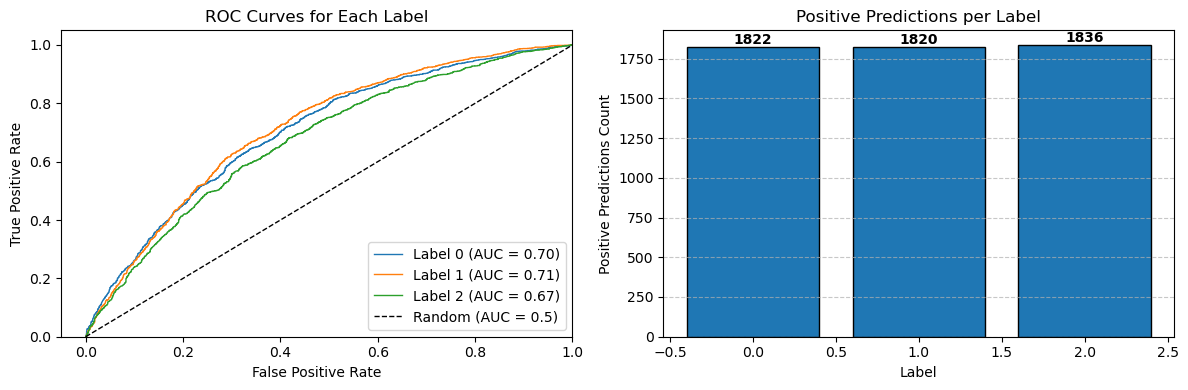

Testing DataLoader 0: 100%|██████████| 105/105 [00:03<00:00, 28.42it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6459886431694031
        test_aupr           0.6688267588615417
       test_auroc           0.6969070434570312
         test_f1            0.6611531376838684
        test_loss           0.6313178539276123
     test_precision         0.6345681548118591
       test_recall          0.6900802254676819
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.6313178539276123,
  'test_acc': 0.6459886431694031,
  'test_auroc': 0.6969070434570312,
  'test_aupr': 0.6688267588615417,
  'test_precision': 0.6345681548118591,
  'test_recall': 0.6900802254676819,
  'test_f1': 0.6611531376838684}]

In [7]:
# Initialize a trainer
trainer = L.Trainer(
    accelerator="gpu",
    devices=[1],
    max_epochs=1,
    gradient_clip_val=1,
    precision="16-mixed",
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)
# Train the model
trainer.fit(seq_model, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(seq_model, dataloaders=test_loader)